# BAIS 409 Deep Learning Project

### Section 1: Project Description
___

#### Dataset Information

This project analyzes Amazon India product listing data to understand what drives customer ratings and how products can be grouped by pricing behavior. The dataset contains 1,465 product listings with pricing, discount, rating, and category information from Amazon.

Because prices are listed in Indian Rupees with comma formatted numbers and discounts stored as percentage strings, Section 3 includes data cleaning to convert all financial columns into usable numeric values before any analysis is performed.

#### Machine Learning Focus

- **Section 4:** Which product features are most important in predicting whether a product is highly rated (4.0+)?
<br><br>
- **Section 5:** Can we predict high ratings using discount percentage alone - and does balancing class weights improve results?
<br><br>
- **Section 6:** Can Amazon products be grouped into distinct pricing/popularity profiles using discount percentage and review count?

<br><br>
Dataset source: Amazon Sales Dataset on Kaggle.
https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset/data

### Section 2: Import Libraries and Data
___

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load Dataset
file_path = '/content/drive/MyDrive/BAIS409_DATA/amazon.csv'

df = pd.read_csv(file_path)
print(df.head(n=10))

   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
5  B08Y1TFSP6  pTron Solero TB301 3A Type-C Data and Fast Cha...   
6  B08WRWPM22  boAt Micro USB 55 Tangle-free, Sturdy Micro US...   
7  B08DDRGWTJ             MI Usb Type-C Cable Smartphone (Black)   
8  B008IFXQFU  TP-Link USB WiFi Adapter for PC(TL-WN725N), N1...   
9  B082LZGK39  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accesso

### Section 2 (Part 2): Install / Setup API
___

In [ ]:
# Install ChatGPT
!pip install chatgpt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 MB 16.8 MB/s eta 0:00:00


In [ ]:
import os
from openai import OpenAI
from google.colab import userdata

api_key = None
try:
    api_key = userdata.get("OPENAI_API_KEY")
except Exception:
    pass

openai.api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError("OpenAI API key not found.")

os.environ["OPENAI_API_KEY"] = api_key
client = OpenAI()
print("API key loaded.")

API key loaded.


### Section 3: Examine and Clean the Data
___

In [ ]:
# Shape of the dataset
df.shape

(1465, 16)

In [ ]:
# Column names
print(df.columns.tolist())

['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']


In [ ]:
# Check data types
df.dtypes

,0
product_id,object
product_name,object
category,object
discounted_price,object
actual_price,object
discount_percentage,object
rating,object
rating_count,object
about_product,object
user_id,object


In [ ]:
# Preview raw values before cleaning
print("discounted_price:", df['discounted_price'].head(3).tolist())
print("actual_price:    ", df['actual_price'].head(3).tolist())
print("discount_%:      ", df['discount_percentage'].head(3).tolist())
print("rating_count:    ", df['rating_count'].head(3).tolist())

discounted_price: ['₹399', '₹199', '₹199']
actual_price:     ['₹1,099', '₹349', '₹1,899']
discount_%:       ['64%', '43%', '90%']
rating_count:     ['24,269', '43,994', '7,928']


In [ ]:
# Clean columns: strip currency symbols, commas, and percent signs
df['discounted_price']    = df['discounted_price'].str.replace('\u20b9', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['actual_price']        = df['actual_price'].str.replace('\u20b9', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '', regex=False).astype(float)
df['rating_count']        = df['rating_count'].str.replace(',', '', regex=False).astype(float)
df['rating']              = pd.to_numeric(df['rating'], errors='coerce')

# Extract the top-level category from the pipe-separated category string
df['category_main'] = df['category'].str.split('|').str[0]

# Create a calculated savings column: how much the customer saves vs original price
df['savings'] = df['actual_price'] - df['discounted_price']

# Drop rows with missing rating_count or rating
df = df.dropna(subset=['rating_count', 'rating'])

print("Shape after cleaning:", df.shape)

Shape after cleaning: (1462, 18)


In [ ]:
# Rename columns for readability
df = df.rename(columns={
    'discounted_price':    'Price',
    'actual_price':        'Original Price',
    'discount_percentage': 'Discount %',
    'rating_count':        'Review Count',
    'category_main':       'Category'
})
print(df.columns.tolist())

['product_id', 'product_name', 'category', 'Price', 'Original Price', 'Discount %', 'rating', 'Review Count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link', 'Category', 'savings']


In [ ]:
# Check for missing values after cleaning
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
Price,0
Original Price,0
Discount %,0
rating,0
Review Count,0
about_product,0
user_id,0


In [ ]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Summary statistics for all numeric columns
df[['Price', 'Original Price', 'Discount %', 'rating', 'Review Count', 'savings']].describe().round(2)

,Price,Original Price,Discount %,rating,Review Count,savings
count,1462.00,1462.00,1462.00,1462.00,1462.00,1462.00
mean,3129.98,5453.09,47.67,4.10,18307.38,2323.11
std,6950.55,10884.47,21.61,0.29,42766.10,4608.57
min,39.00,39.00,0.00,2.00,2.00,0.00
25%,325.00,800.00,32.00,4.00,1191.50,370.25
50%,799.00,1670.00,50.00,4.10,5179.00,800.00
75%,1999.00,4321.25,63.00,4.30,17342.25,1959.00
max,77990.00,139900.00,94.00,5.00,426973.00,61910.00


The dataset is clean with no nulls remaining and no duplicate rows. Price and discount columns have been successfully converted from string format to numeric values. A `savings` column (Original Price minus Price) has been added as an additional feature, and a top-level `Category` has been extracted from the nested pipe-separated category string.

### Section 4: Which product features best predict whether a product is highly rated?
___

A product is labeled **high rating (1)** if its rating is 4.0 or above, and **low rating (0)** otherwise. A Random Forest Classifier is trained across all available features to determine which signals matter most.

In [ ]:
# Create binary target: 1 = high rating (>= 4.0), 0 = low rating
df['high_rating'] = (df['rating'] >= 4.0).astype(int)

print("High rating distribution:")
print(df['high_rating'].value_counts())
print()
print(f"High rating rate: {df['high_rating'].mean():.1%}")

High rating distribution:
high_rating
1    1109
0     353
Name: count, dtype: int64

High rating rate: 75.9%


In [ ]:
# Define features and encode the categorical column
X = pd.get_dummies(df[['Discount %', 'Review Count', 'Price', 'Original Price', 'savings', 'Category']], drop_first=True)
y = df['high_rating']

# 80/20 Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 1169
Testing samples:  293


In [ ]:
# Train Random Forest Classifier with balanced class weights
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
# Rank feature importances
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("Top 10 Most Important Features:")
print(importance.head(10).round(4))

Top 10 Most Important Features:
Review Count                      0.2437
Price                             0.1826
Discount %                        0.1761
savings                           0.1655
Original Price                    0.1633
Category_Computers&Accessories    0.0304
Category_Home&Kitchen             0.0172
Category_Electronics              0.0148
Category_OfficeProducts           0.0046
Category_MusicalInstruments       0.0010
dtype: float64


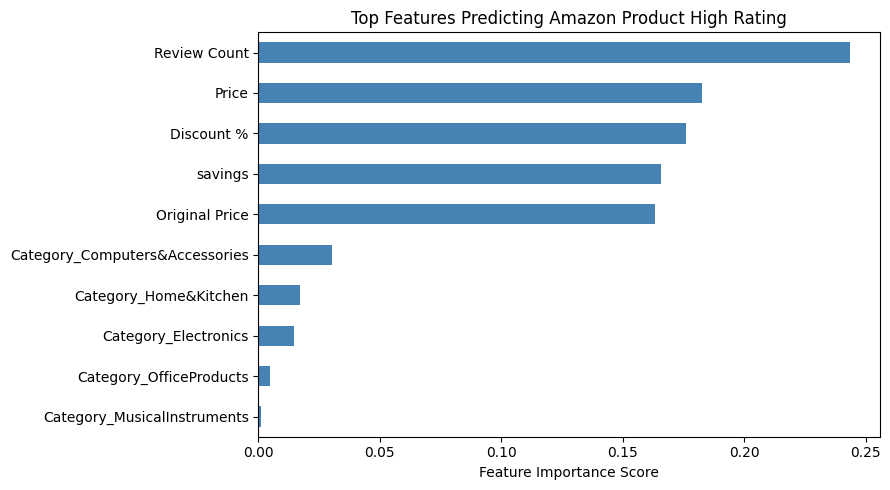

In [ ]:
# Visualization: horizontal bar chart of top 10 features
importance.head(10).plot(kind='barh', color='steelblue', figsize=(9, 5))
plt.title("Top Features Predicting Amazon Product High Rating")
plt.xlabel("Feature Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# GPT Prompt - Feature Importance Analysis
prompt1 = (
    "You are analyzing an Amazon product dataset to understand what drives high customer ratings (4.0+).\n\n"
    "A Random Forest Classifier was trained on pricing, discount, review count, savings, and category features.\n\n"
    f"Top 10 Feature Importances:\n{importance.head(10).round(4).to_string()}\n\n"
    "Answer the following in bullet point form (1-2 sentences each):\n"
    "1. Which features have the most influence on predicting a high rating?\n"
    "2. What does this tell us about what Amazon shoppers respond to?\n"
    "3. Are there any surprising or counterintuitive results in the rankings?\n"
    "4. What does this suggest for sellers trying to improve their product ratings?\n\n"
    "End with one sentence summarizing the overall finding."
)

response1 = client.responses.create(
    model="gpt-4o-mini",
    input=prompt1,
)

print(response1.output_text)

1. **Most Influential Features**: The features with the most influence on predicting a high rating are Review Count (0.2437), Price (0.1826), and Discount % (0.1761). These suggest that a higher volume of reviews, competitive pricing, and attractive discounts are critical for scoring well with customers.

2. **Customer Response Insights**: This indicates that Amazon shoppers value social proof (through review count), favorable pricing, and discounts when making purchasing decisions. Customers are likely to feel more confident about products with substantial positive feedback and perceived financial benefits.

3. **Surprising Results**: It is surprising that the specific category features have much lower importance, particularly categories like Computers & Accessories and Home & Kitchen, which are often expected to have significant influences on purchasing decisions. This suggests that product-specific factors like pricing and reviews may outweigh category effects.

4. **Implications fo

### Section 5: Can discount percentage alone predict high ratings - and does balancing class weights help?
___

This section isolates **Discount %** as a single predictor. Since ~76% of products are highly rated, the dataset is imbalanced. Two models are compared to see whether correcting for class imbalance improves the ability to catch low-rated products.

In [ ]:
# Single feature model: Discount % only
X_disc = df[['Discount %']]

X_train, X_test, y_train, y_test = train_test_split(
    X_disc, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Model A: Standard (no class weight adjustment)
model_standard = RandomForestClassifier(random_state=42)
model_standard.fit(X_train, y_train)
y_pred_standard = model_standard.predict(X_test)

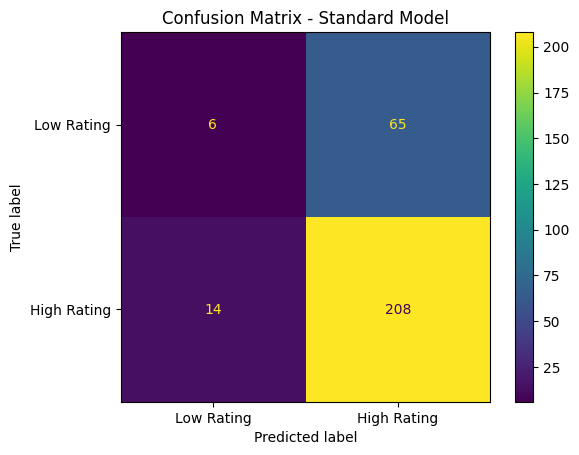

In [ ]:
# Confusion Matrix - Standard Model
cm_standard = confusion_matrix(y_test, y_pred_standard)
ConfusionMatrixDisplay(cm_standard, display_labels=['Low Rating', 'High Rating']).plot()
plt.title("Confusion Matrix - Standard Model")
plt.show()

In [ ]:
# Classification Report - Standard Model
print("Standard Model:")
print(classification_report(y_test, y_pred_standard, target_names=['Low Rating', 'High Rating']))

Standard Model:
              precision    recall  f1-score   support

  Low Rating       0.30      0.08      0.13        71
 High Rating       0.76      0.94      0.84       222

    accuracy                           0.73       293
   macro avg       0.53      0.51      0.49       293
weighted avg       0.65      0.73      0.67       293



#### Standard Model Analysis
The standard model heavily favors predicting high ratings because that is the dominant class. It struggles to correctly identify low-rated products, which is the harder and more valuable prediction.

In [ ]:
# Model B: Balanced class weights
model_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)

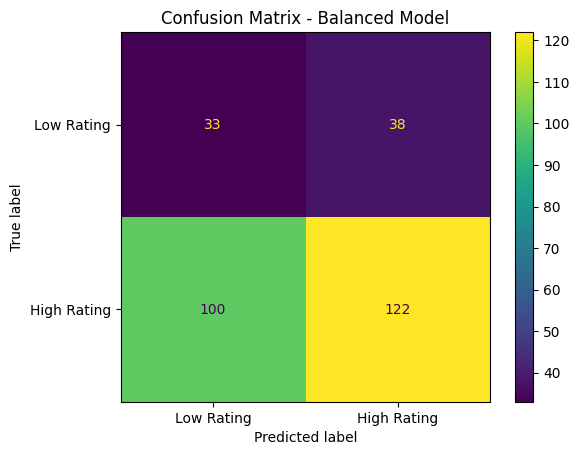

In [ ]:
# Confusion Matrix - Balanced Model
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
ConfusionMatrixDisplay(cm_balanced, display_labels=['Low Rating', 'High Rating']).plot()
plt.title("Confusion Matrix - Balanced Model")
plt.show()

In [ ]:
# Classification Report - Balanced Model
print("Balanced Model:")
print(classification_report(y_test, y_pred_balanced, target_names=['Low Rating', 'High Rating']))

Balanced Model:
              precision    recall  f1-score   support

  Low Rating       0.25      0.46      0.32        71
 High Rating       0.76      0.55      0.64       222

    accuracy                           0.53       293
   macro avg       0.51      0.51      0.48       293
weighted avg       0.64      0.53      0.56       293



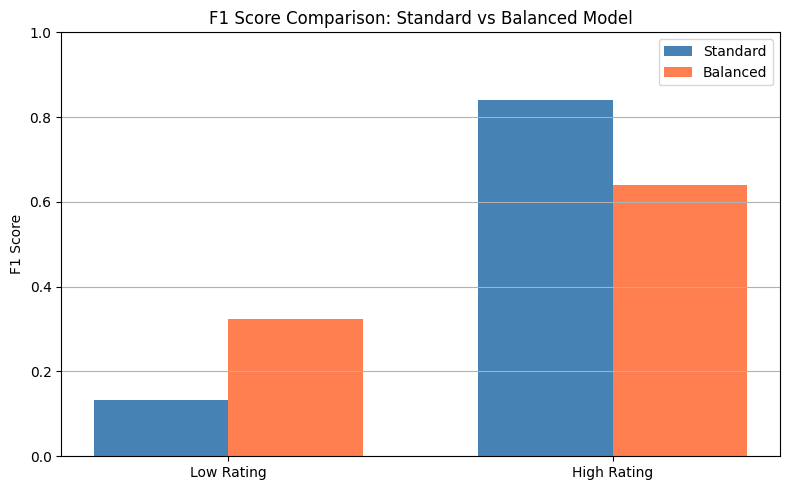

In [ ]:
# Side-by-side F1 score comparison bar chart
labels = ['Low Rating', 'High Rating']

f1_std = [f1_score(y_test, y_pred_standard, pos_label=0),
          f1_score(y_test, y_pred_standard, pos_label=1)]
f1_bal = [f1_score(y_test, y_pred_balanced, pos_label=0),
          f1_score(y_test, y_pred_balanced, pos_label=1)]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, f1_std, width, label='Standard', color='steelblue')
ax.bar(x + width/2, f1_bal, width, label='Balanced',  color='coral')

ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Comparison: Standard vs Balanced Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# GPT Prompt - Model Comparison
prompt2 = (
    "You are analyzing two Random Forest models that predict whether an Amazon product has a high rating (4.0+) using only Discount % as a feature.\n\n"
    "The dataset is imbalanced: ~76% of products are highly rated.\n\n"
    "Confusion Matrix Format:\n"
    "[[True Negatives (Low predicted Low), False Positives (Low predicted High)],\n"
    " [False Negatives (High predicted Low), True Positives (High predicted High)]]\n\n"
    f"Standard Model:\n{cm_standard}\n\n"
    f"Balanced Model:\n{cm_balanced}\n\n"
    "Answer in concise bullet points (1-2 sentences each):\n"
    "1. How does the standard model perform on low-rated vs high-rated products?\n"
    "2. How does balancing class weights change detection of low-rated products?\n"
    "3. What tradeoff does balancing introduce?\n"
    "4. What does this tell us about discount percentage as a predictor of rating?\n\n"
    "End with a highlighted conclusion: which model is more appropriate and why?"
)

response2 = client.responses.create(
    model="gpt-4o-mini",
    input=prompt2,
)

print(response2.output_text)

1. **Standard Model Performance**: The standard model shows a high rate of false positives (65) when predicting high-rated products, indicating it struggles to correctly identify low-rated products, with only 6 correct predictions.

2. **Impact of Balancing Class Weights**: Balancing class weights significantly improves the detection of low-rated products (14 true positives to 100 in the balanced model), which indicates better classification of the minority class.

3. **Tradeoff of Balancing**: While balancing improves detection of low-rated products, it introduces more false negatives for high-rated products (208 in standard versus 122 in balanced), suggesting a decreased sensitivity for predicting high-rated products.

4. **Insight on Discount Percentage**: The findings imply that while discount percentage can give some predictive power, it is not a strong indicator alone of product ratings, especially given the notable drop in high-rated product identification in the balanced model.

### Section 6: Can Amazon products be grouped into distinct pricing and popularity profiles?
___

K-Means clustering is applied using **Discount %** and **Review Count** to discover natural product groupings. These two features capture how aggressively a product is discounted vs. how popular it is. Rating is not used in clustering - only for interpretation afterward.

In [ ]:
# Features for clustering
X_clust = df[['Discount %', 'Review Count']]

# Scale to 0-1 so review count does not dominate due to its larger magnitude
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_clust)

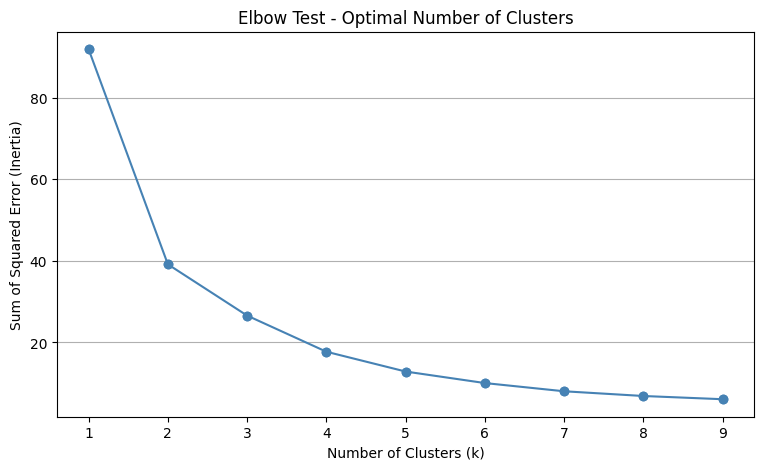

In [ ]:
# Elbow Test - determine optimal number of clusters
sse = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 10), sse, marker='o', color='steelblue')
plt.scatter(range(1, 10), sse, color='steelblue')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Error (Inertia)")
plt.title("Elbow Test - Optimal Number of Clusters")
plt.grid(axis='y')
plt.show()

The elbow plot shows where adding more clusters stops meaningfully reducing error. The bend at **k=3** indicates three natural product groupings in this dataset.

In [ ]:
# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
# Cluster summary - average values per group
cluster_summary = df.groupby('Cluster')[['Discount %', 'Review Count', 'rating']].mean().round(2)
print("Cluster Summary:")
print(cluster_summary)
print()
print("Cluster Sizes:")
print(df['Cluster'].value_counts())

Cluster Summary:
         Discount %  Review Count  rating
Cluster                                  
0             18.00      19182.54    4.17
1             69.55      20804.69    4.06
2             45.52      15351.16    4.09

Cluster Sizes:
Cluster
2    563
1    541
0    358
Name: count, dtype: int64


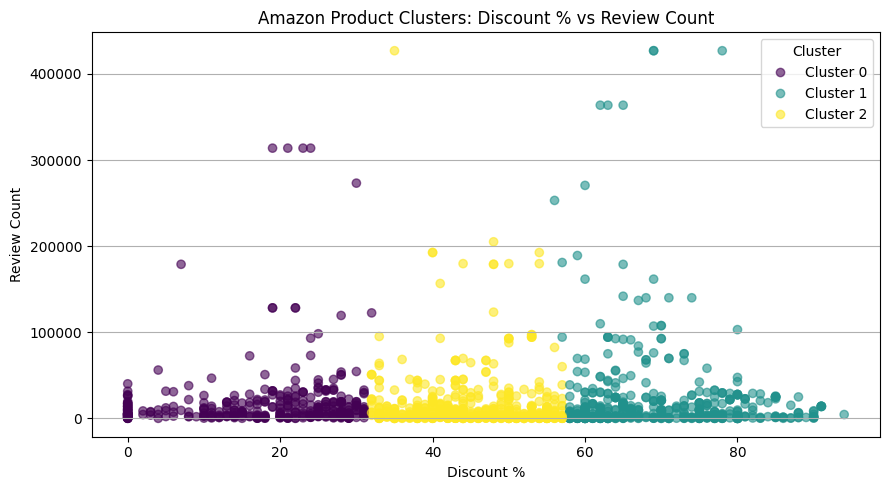

In [ ]:
# Scatter plot: colored by cluster label
plt.figure(figsize=(9, 5))
scatter = plt.scatter(
    df['Discount %'],
    df['Review Count'],
    c=df['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("Discount %")
plt.ylabel("Review Count")
plt.title("Amazon Product Clusters: Discount % vs Review Count")

handles, _ = scatter.legend_elements()
plt.legend(handles, ['Cluster 0', 'Cluster 1', 'Cluster 2'], title="Cluster")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

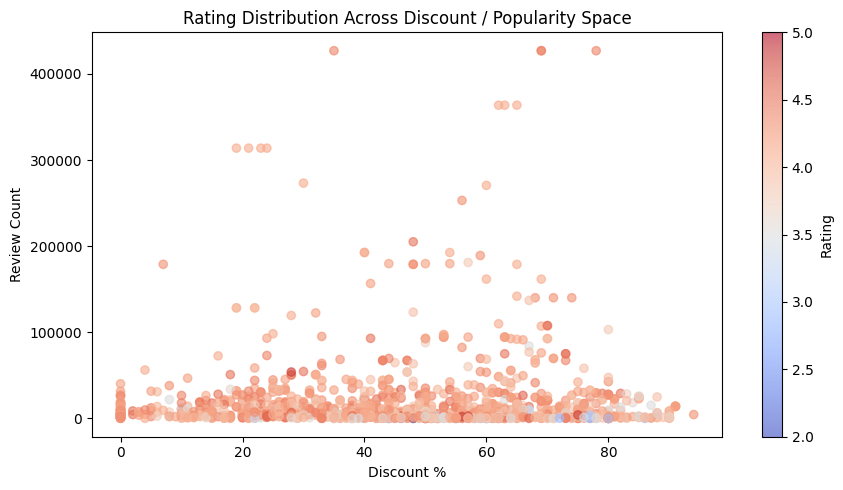

In [ ]:
# Scatter plot: same axes but colored by rating to check alignment
plt.figure(figsize=(9, 5))
sc = plt.scatter(
    df['Discount %'],
    df['Review Count'],
    c=df['rating'],
    cmap='coolwarm',
    alpha=0.6
)

plt.colorbar(sc, label='Rating')
plt.xlabel("Discount %")
plt.ylabel("Review Count")
plt.title("Rating Distribution Across Discount / Popularity Space")
plt.tight_layout()
plt.show()

In [ ]:
# GPT Prompt - Clustering Analysis
prompt3 = (
    "You are analyzing K-Means clustering results from an Amazon product dataset.\n\n"
    "Three clusters were formed using Discount % and Review Count only.\n"
    "Product rating was NOT used in clustering - only included for interpretation.\n\n"
    f"Cluster Summary (averages):\n{cluster_summary.to_string()}\n\n"
    f"Cluster Sizes:\n{df['Cluster'].value_counts().to_string()}\n\n"
    "Answer in concise bullet points (1-2 sentences each):\n"
    "1. Describe each cluster in plain terms - what type of product does it represent?\n"
    "2. How do the clusters differ in discount behavior and popularity?\n"
    "3. Does rating align with the clusters or is it scattered randomly across groups?\n"
    "4. What practical insight could an Amazon seller take from these profiles?\n\n"
    "End with one sentence concluding whether meaningful product profiles exist in this data."
)

response3 = client.responses.create(
    model="gpt-4o-mini",
    input=prompt3,
)

print(response3.output_text)

### Cluster Descriptions:
1. **Cluster 0**: Represents products with a low discount (18%) and high popularity (nearly 19,183 reviews), likely indicating premium items that maintain sales without heavy discounts.
2. **Cluster 1**: Comprises highly discounted items (over 69%) that are also quite popular (over 20,804 reviews), suggesting clearance or promotional products appealing to budget-conscious consumers.
3. **Cluster 2**: Features mid-range discounts (about 45%) and moderate popularity (around 15,351 reviews), possibly indicating seasonal or niche products with decent buyer interest.

### Differences in Discount Behavior and Popularity:
- **Discount Behavior**: Cluster 1 has the highest discount percentage, while Cluster 0 has the lowest, highlighting a clear distinction in pricing strategies.
- **Popularity**: Clusters 1 and 0 are more popular, with high review counts, while Cluster 2 is less popular, indicating a correlation between discount levels and consumer interest.

### Rat

### Section 7: Conclusion
___

In [ ]:
# Collect all GPT summaries for final synthesis
summary1 = response1.output_text
summary2 = response2.output_text
summary3 = response3.output_text

prompt_final = (
    "You are a data analyst writing a final summary for an Amazon product ratings project.\n\n"
    f"Section 4 - Feature Importance (Random Forest, full features):\n{summary1}\n\n"
    f"Section 5 - Discount % Only Model (Standard vs Balanced):\n{summary2}\n\n"
    f"Section 6 - K-Means Clustering (Discount % vs Review Count):\n{summary3}\n\n"
    "Task: Write a final section titled 'Overall Product Insights'.\n\n"
    "Requirements:\n"
    "- Write 4-6 bullet points\n"
    "- Each bullet must be exactly one sentence\n"
    "- Synthesize insights ACROSS all three sections - do not restate individual results\n"
    "- Focus on actionable takeaways for a seller or product manager\n"
    "- Do NOT repeat exact numbers unless essential\n"
    "- Tone: professional, concise, data-driven\n\n"
    "Output only the 'Overall Product Insights' section."
)

final_response = client.responses.create(
    model="gpt-4o-mini",
    input=prompt_final,
)

print(final_response.output_text)

### Overall Product Insights

- Prioritizing review count, competitive pricing, and attractive discounts is essential for enhancing product ratings and consumer trust.  
- Strategies must include targeted promotions for high-discount items while simultaneously emphasizing the value of premium products with minimal discounts.  
- Sellers should adopt a balanced approach in predictive modeling to accurately capture both high-rated and low-rated products to refine their inventory strategies.  
- Understanding the distinct consumer segments represented in clustering analysis can guide personalized marketing efforts and optimize product positioning.  
- Continuous monitoring of customer feedback and sales performance is crucial to adaptively refine discount and pricing strategies based on market responsiveness.  
- Fostering a robust review generation strategy will not only influence ratings positively but also serve as a powerful tool in mitigating the effects of competitive pricing pressu